In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("/content/Telco-Customer-Churn-cleaned.csv")
print (df)

      customerID  gender SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female            No     Yes         No       1   
1     5575-GNVDE    Male            No      No         No      34   
2     3668-QPYBK    Male            No      No         No       2   
3     7795-CFOCW    Male            No      No         No      45   
4     9237-HQITU  Female            No      No         No       2   
...          ...     ...           ...     ...        ...     ...   
7038  6840-RESVB    Male            No     Yes        Yes      24   
7039  2234-XADUH  Female            No     Yes        Yes      72   
7040  4801-JZAZL  Female            No     Yes        Yes      11   
7041  8361-LTMKD    Male           Yes     Yes         No       4   
7042  3186-AJIEK    Male            No      No         No      66   

     InternetService        Contract  MonthlyCharges  TotalCharges Churn  
0                DSL  Month-to-month           29.85         29.85    No  
1                DSL 

In [13]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
#view data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,DSL,Month-to-month,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,DSL,One year,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,DSL,Month-to-month,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,DSL,One year,42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Fiber optic,Month-to-month,70.70,151.65,Yes


In [15]:
#check shape
df.shape

(7043, 11)

In [16]:
#understand dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   object 
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   InternetService  7043 non-null   object 
 7   Contract         7043 non-null   object 
 8   MonthlyCharges   7043 non-null   float64
 9   TotalCharges     7043 non-null   float64
 10  Churn            7043 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 605.4+ KB


In [17]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [18]:
#check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
InternetService,0
Contract,0
MonthlyCharges,0
TotalCharges,0


In [19]:
#CLEAN TOTAL CHARGES
#1. Convert to numeric
df['Total_charges']=pd.to_numeric(df['TotalCharges'],
    errors='coerce')

In [20]:
#check missing values
df['TotalCharges'].isnull().sum()

np.int64(0)

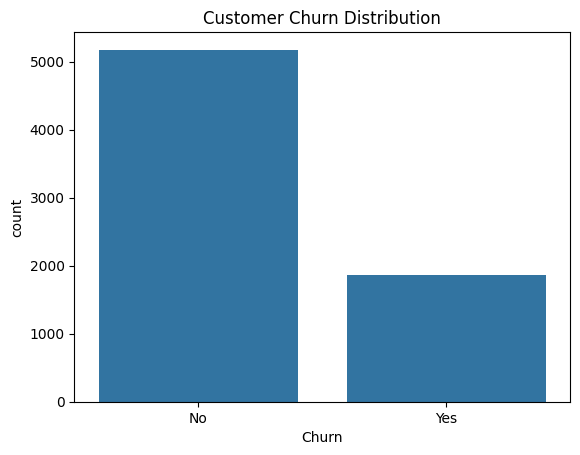

In [21]:
# check churn distribution
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

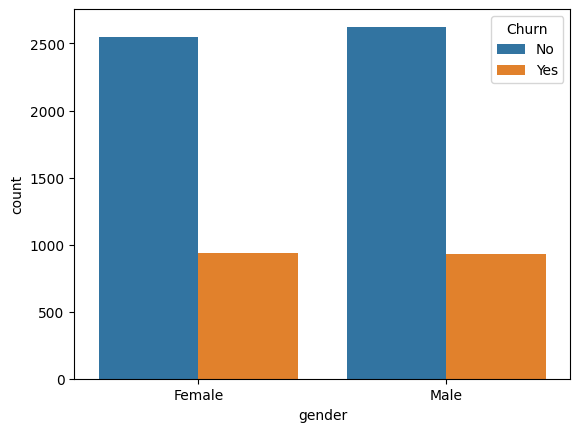

In [22]:
#Gender vs churn

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.show()

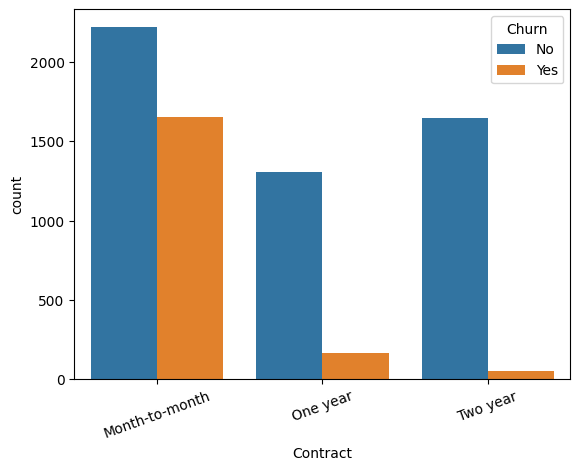

In [23]:
#Contract vs churn
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)
plt.show()

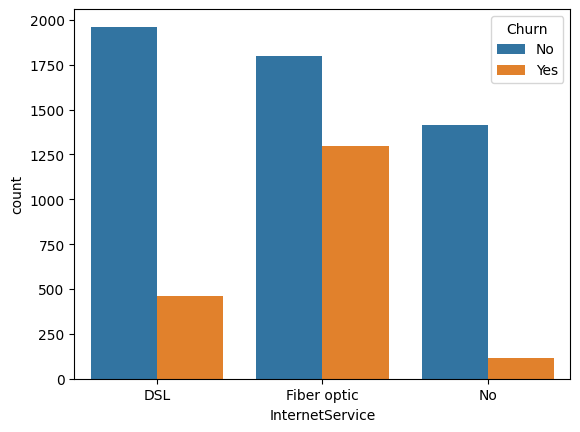

In [24]:
#internet vs churn
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

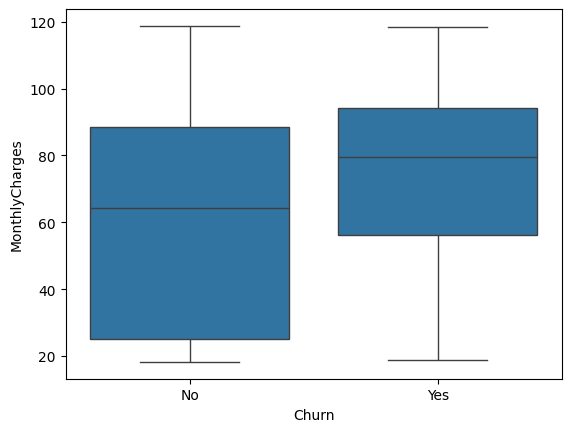

In [25]:
#monthly charges analysis
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

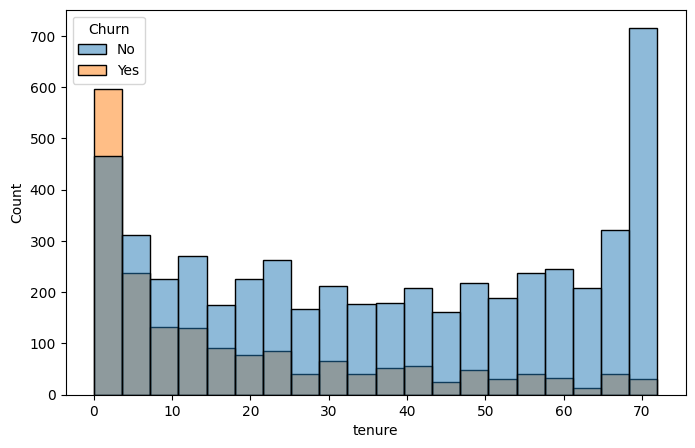

In [26]:
#tenue analysis
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=20
)

plt.show()

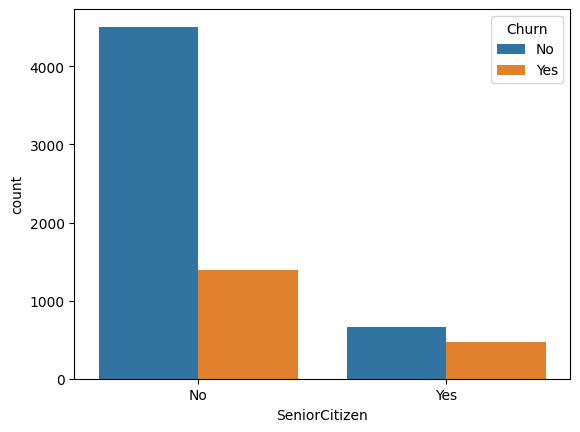

In [27]:
#senior citizen analysis
sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.show()

In [28]:
#correlatio heatmap

#1. Convert Churn to numbers
df['Churn_Num'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

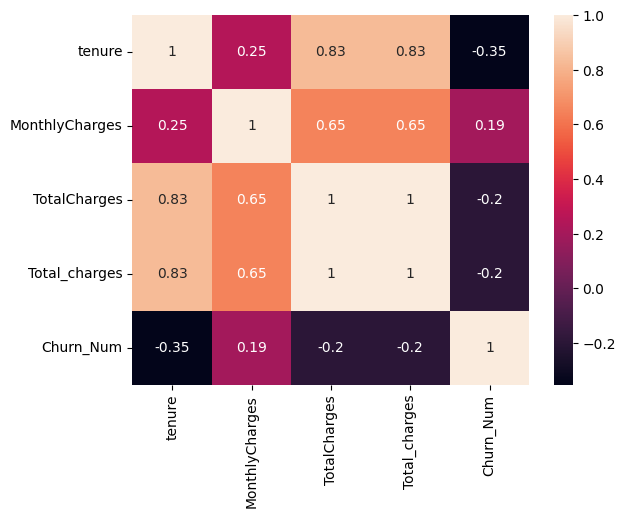

In [29]:
#heatmap
corr = df.select_dtypes(include='number')

sns.heatmap(
    corr.corr(),
    annot=True
)

plt.show()

In [30]:
#Save Clean Dataset

df.to_csv(
    "cleaned_customer_churn.csv",
    index=False
)